In [33]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.tree import plot_tree

from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import DecisionBoundaryDisplay

import pandas as pd
import seaborn as sns

In [3]:
dataset = load_iris()

# Engenharia de atributos da Iris

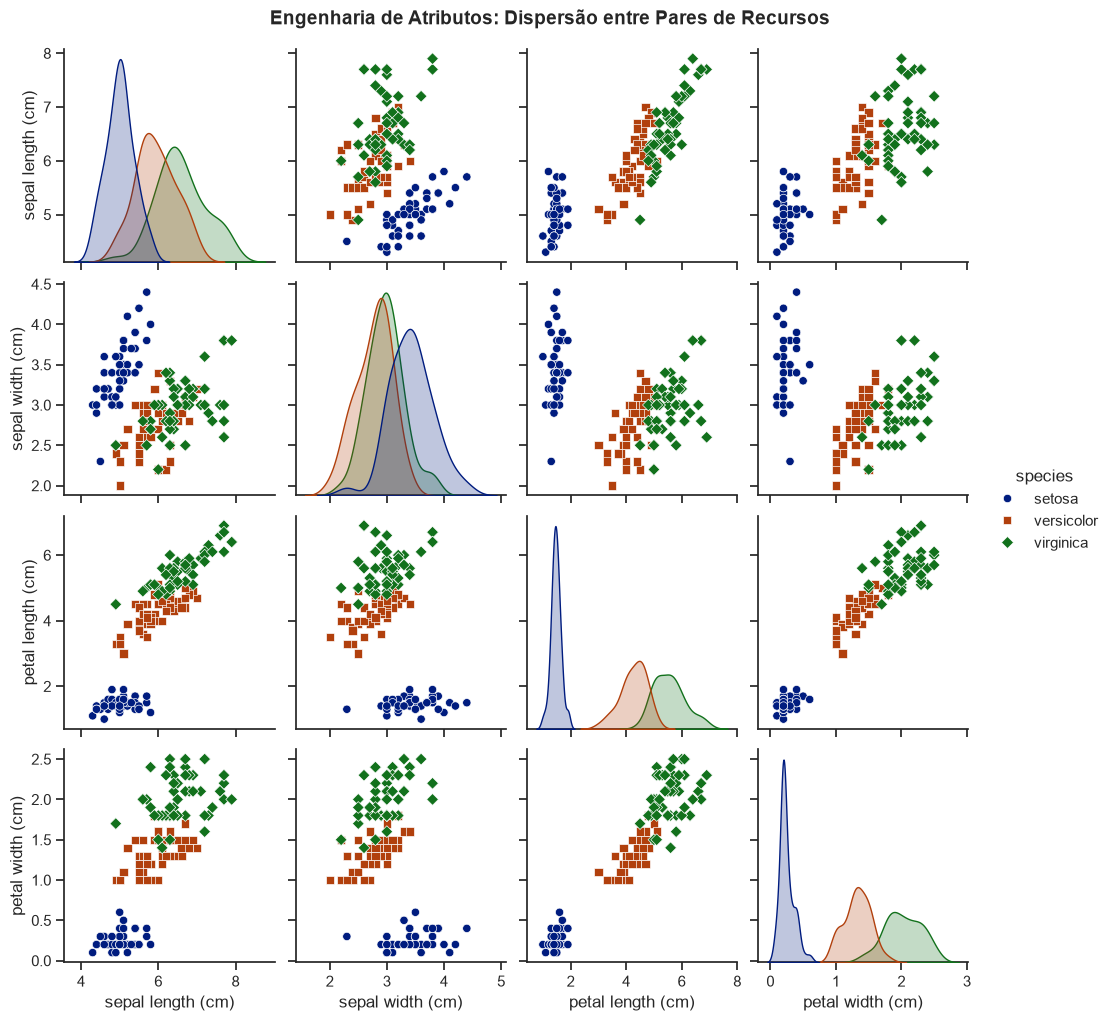

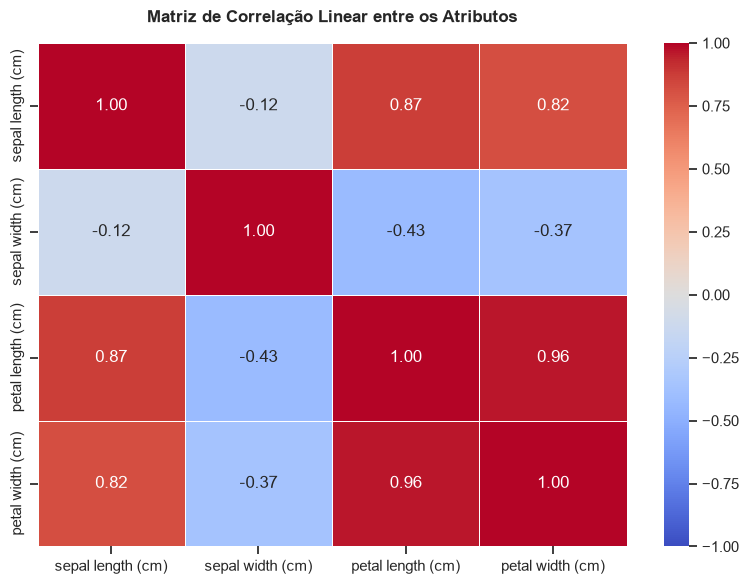

In [34]:
# 1. Carrega os dados e transforma em um DataFrame do Pandas para facilitar os gráficos
dataset = load_iris()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
# Adiciona a coluna de espécies para colorir o primeiro gráfico
df["species"] = [dataset.target_names[i] for i in dataset.target]

# --- GRÁFICO 1: Matriz de Distribuição e Dispersão (Pairplot) ---
# Mostra como cada par de variáveis se comporta e como as espécies se separam
sns.set_theme(style="ticks")
pair_plot = sns.pairplot(df, hue="species", palette="dark", markers=["o", "s", "D"])
pair_plot.fig.suptitle(
    "Engenharia de Atributos: Dispersão entre Pares de Recursos",
    y=1.02,
    fontsize=14,
    fontweight="bold",
)
plt.show()

# --- GRÁFICO 2: Mapa de Calor da Correlação (Heatmap) ---
# Mostra numericamente quais atributos são melhores para prever uns aos outros
plt.figure(figsize=(8, 6))

# Calculamos a correlação apenas das colunas numéricas (excluindo o texto da espécie)
df_numerico = df.drop(columns=["species"])
matriz_correlacao = df_numerico.corr()

# Desenha o heatmap
sns.heatmap(
    matriz_correlacao,
    annot=True,  # Mostra os números dentro dos quadrados
    cmap="coolwarm",  # Azul = Correlação negativa, Vermelho = Correlação positiva
    vmin=-1,
    vmax=1,  # Limites da correlação
    linewidths=0.5,
    fmt=".2f",
)

plt.title(
    "Matriz de Correlação Linear entre os Atributos",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.tight_layout()
plt.show()

# Regressao de todos os valores por pares


Acurácia da Arvore Treino 0:  0.8580664478103286
Acurácia da Arvore Teste 0:  0.8393663739387144


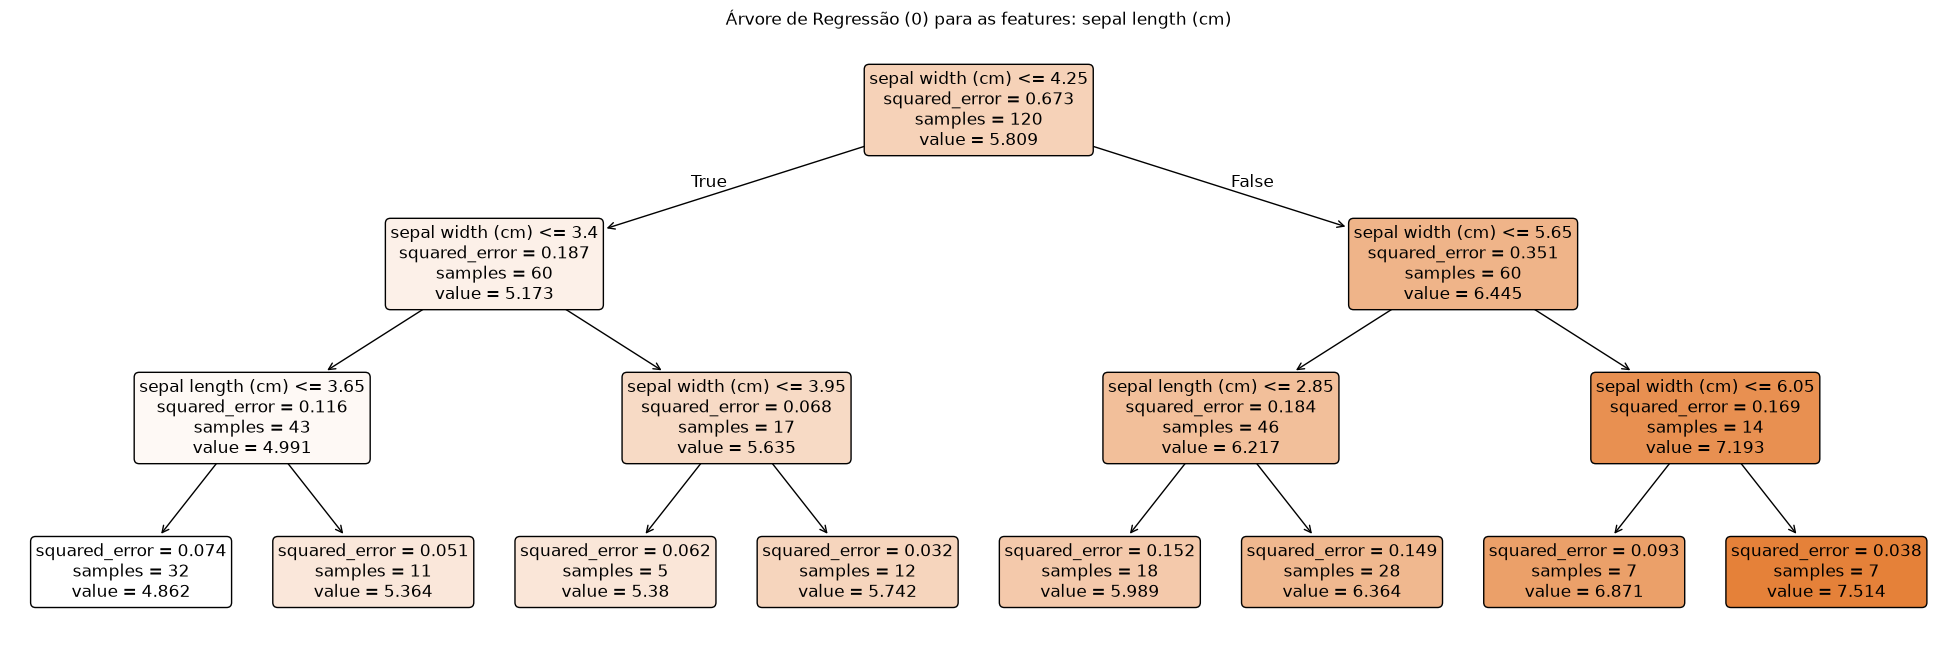

Acurácia da Arvore Treino 1:  0.7425014228101705
Acurácia da Arvore Teste 1:  0.10414575699358963


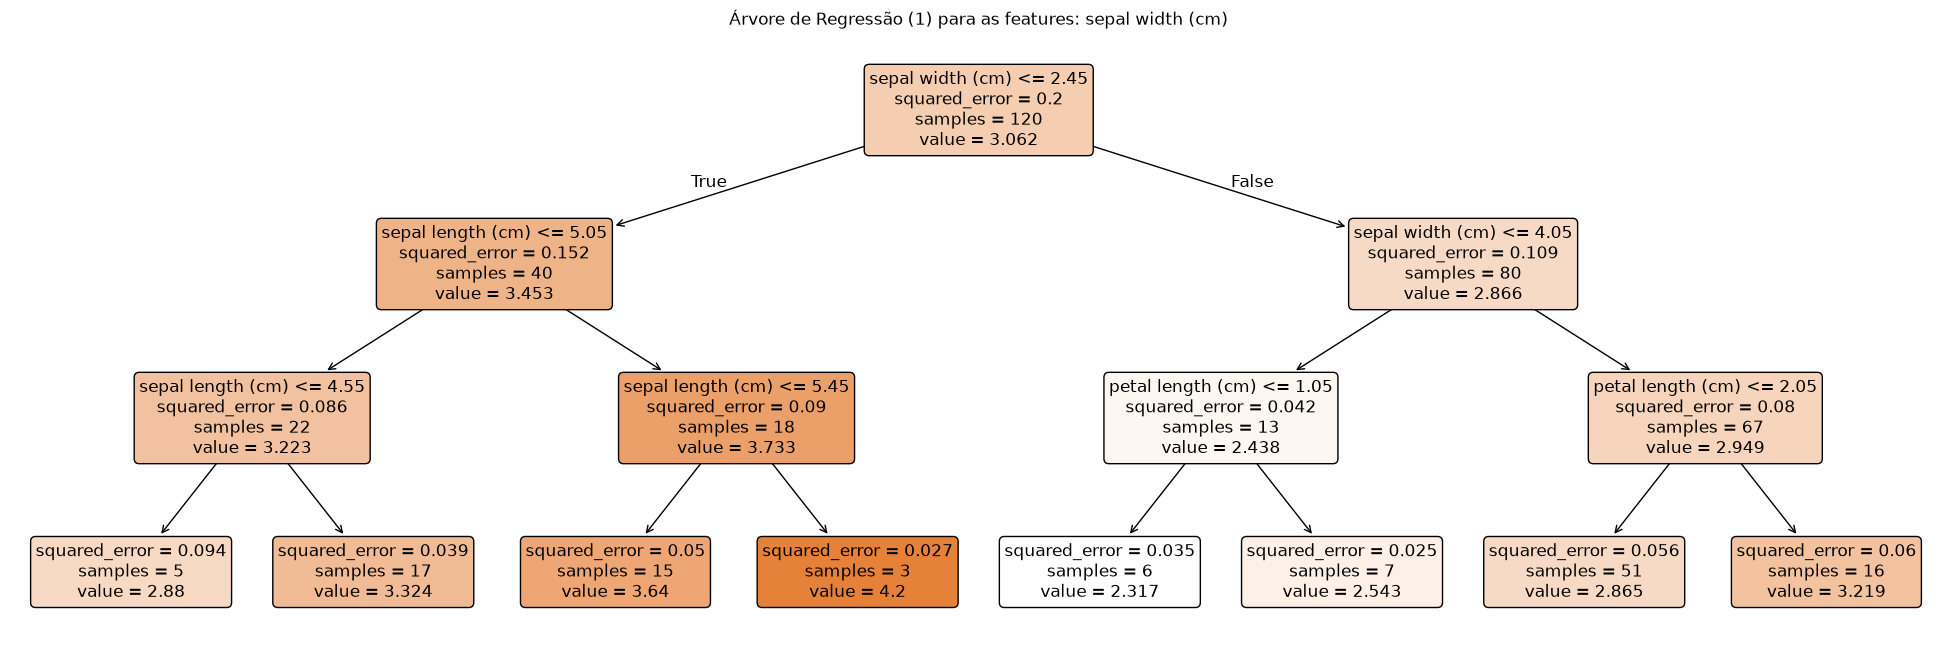

Acurácia da Arvore Treino 2:  0.9693670943540881
Acurácia da Arvore Teste 2:  0.9587939342533705


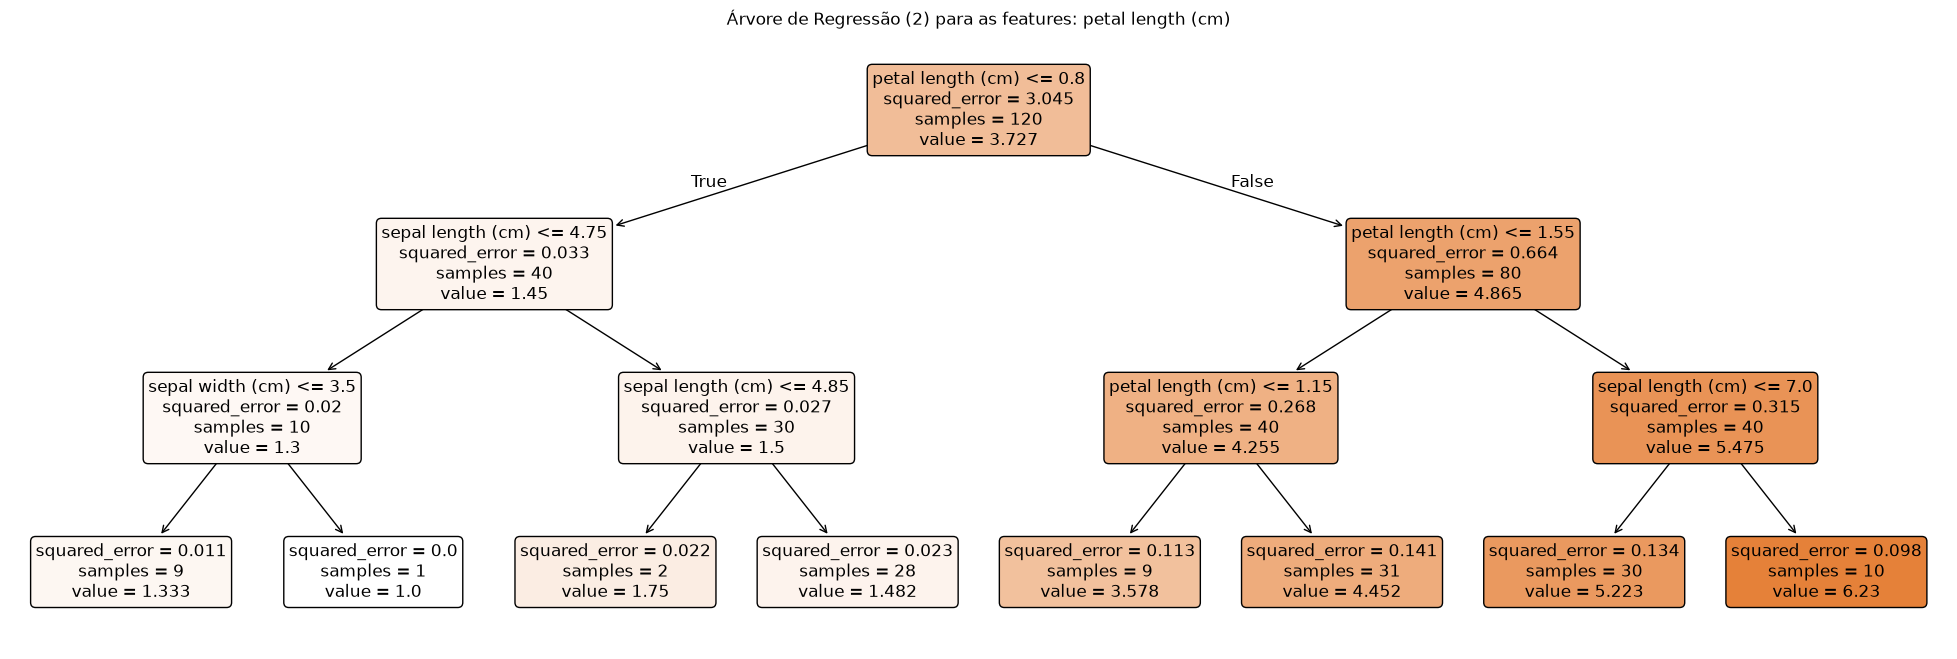

Acurácia da Arvore Treino 3:  0.9479890533227744
Acurácia da Arvore Teste 3:  0.9176636830278013


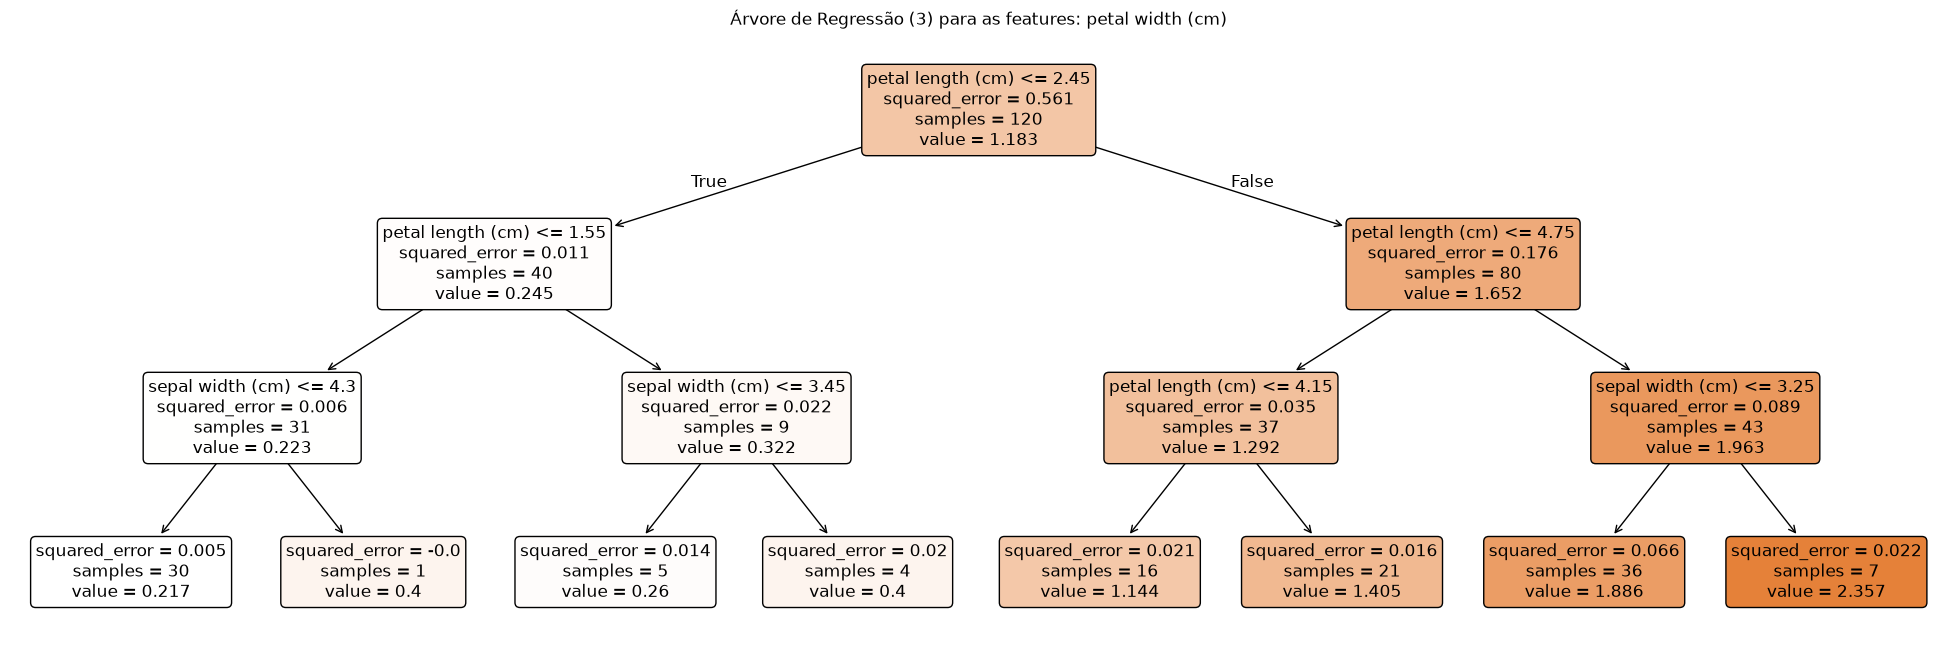

In [31]:
for i in range(4):
    X = np.delete(dataset.data, i, axis=1)  
    Y = dataset.data[:, i]  # Usando a última coluna como variável alvo


    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    # Train
    arvore = DecisionTreeRegressor(max_depth=3, random_state=42).fit(x_train, y_train)


    print("Acurácia da Arvore Treino " + str(i) + ": ", arvore.score(x_train, y_train))
    print("Acurácia da Arvore Teste " + str(i) + ": ", arvore.score(x_test, y_test))

    plt.figure(figsize=(25,8))

    plot_tree(
        arvore,
        feature_names= dataset.feature_names,
        filled=True,  # Pinta os nós baseado no valor previsto
        rounded=True,
        fontsize=12,
    )

    plt.title("Árvore de Regressão (" + str(i) + ") para as features: " + dataset.feature_names[i])

    plt.show()

# Graficos das regressoes

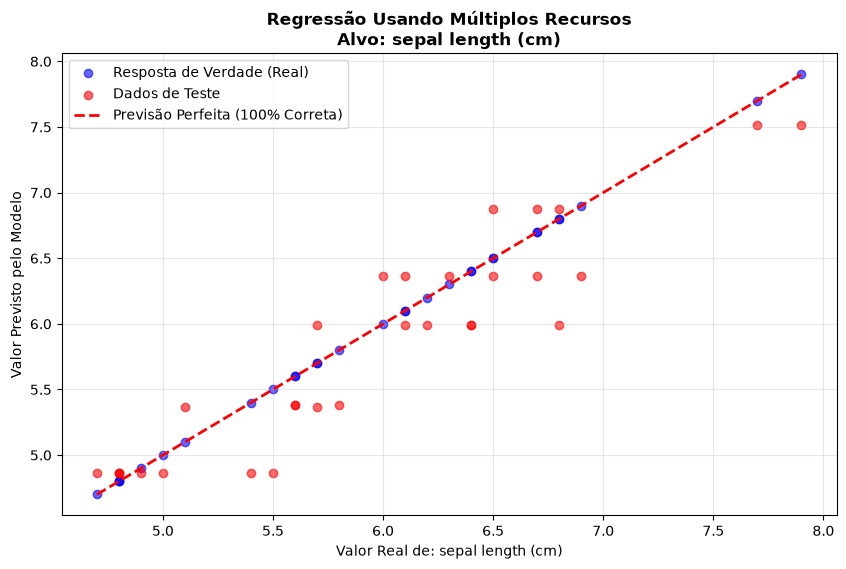

--- Métricas do Modelo Completo (sepal length (cm))---
Erro Quadrático Médio (MSE): 0.11
R² Score (Acurácia da Regressão): 0.84


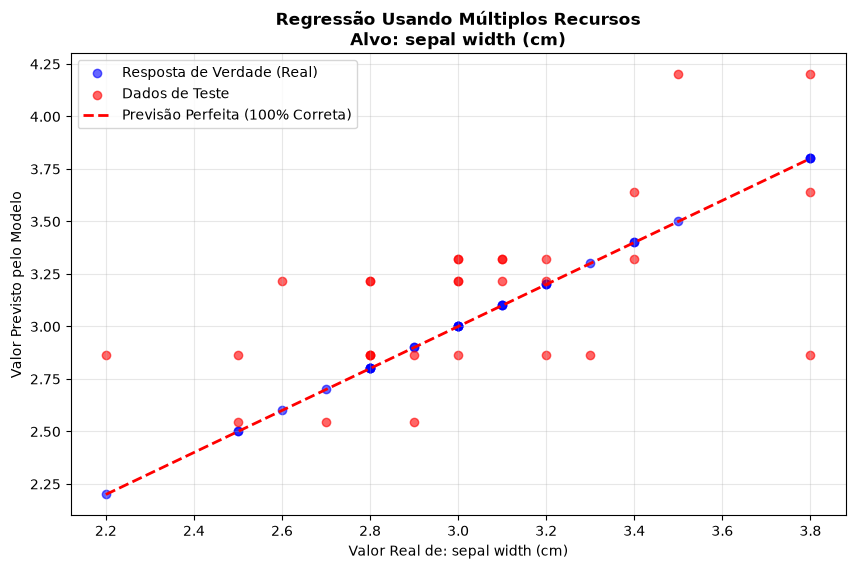

--- Métricas do Modelo Completo (sepal width (cm))---
Erro Quadrático Médio (MSE): 0.13
R² Score (Acurácia da Regressão): 0.10


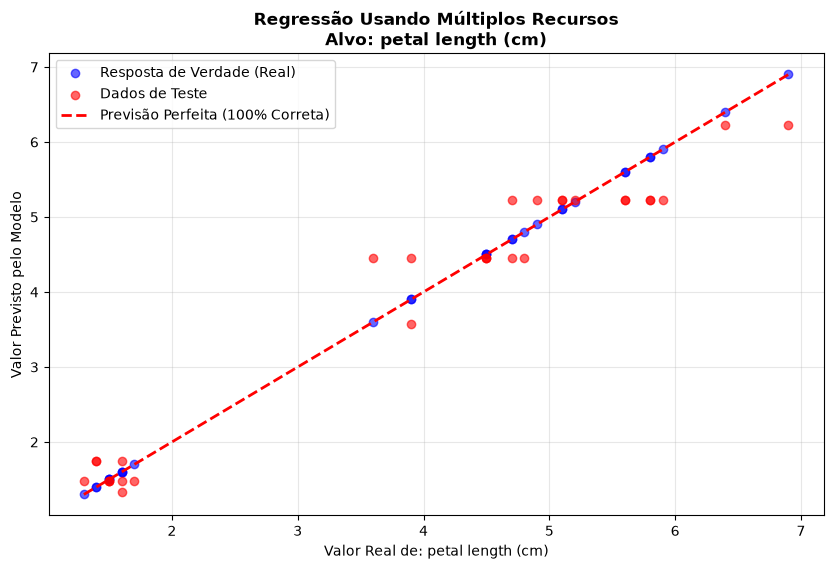

--- Métricas do Modelo Completo (petal length (cm))---
Erro Quadrático Médio (MSE): 0.14
R² Score (Acurácia da Regressão): 0.96


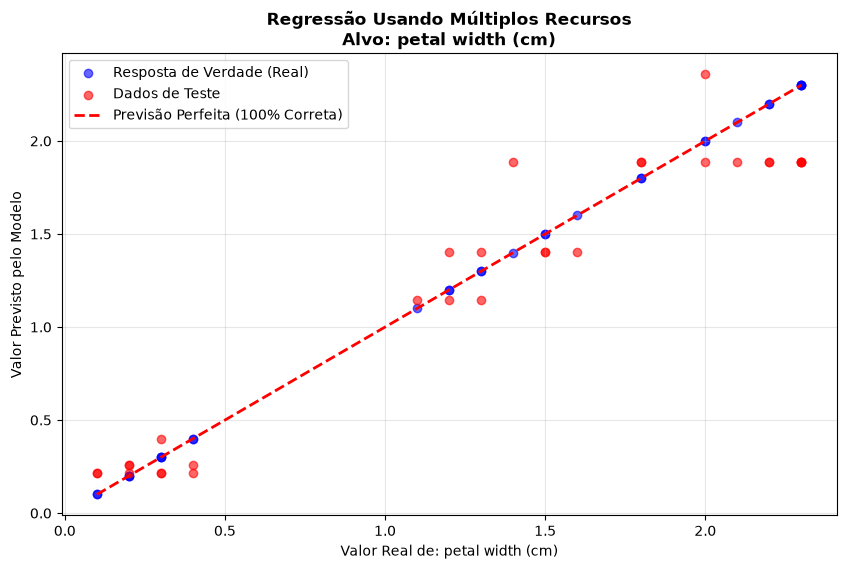

--- Métricas do Modelo Completo (petal width (cm))---
Erro Quadrático Médio (MSE): 0.05
R² Score (Acurácia da Regressão): 0.92


In [29]:
for i in range(4):
    X = np.delete(dataset.data, i, axis=1)  
    Y = dataset.data[:, i]  # Usando a última coluna como variável alvo

    x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

    # Train
    arvore = DecisionTreeRegressor(max_depth=3, random_state=42).fit(x_train, y_train)

    predictions = arvore.predict(x_test)

    plt.figure(figsize=(10, 6))

    # Plota os pontos reais de treino e teste
    #plt.scatter(y_train, predictions, color="blue", alpha=0.6, label="Dados de Treino")
    plt.scatter(y_test, y_test, color="blue", alpha=0.6, label="Resposta de Verdade (Real)")
    plt.scatter(y_test, predictions, color="red", alpha=0.6, label="Dados de Teste")

    # Cria uma linha contínua para mostrar a "curva/degrau" de previsão do modelo
    linha_ideal = np.linspace(y_test.min(), y_test.max(), 100)
    plt.plot(linha_ideal, linha_ideal, color="red", linestyle="--", linewidth=2, label="Previsão Perfeita (100% Correta)")

    # Configurações do gráfico
    plt.xlabel(f"Valor Real de: {dataset.feature_names[i]}")
    plt.ylabel(f"Valor Previsto pelo Modelo")
    plt.title(f"Regressão Usando Múltiplos Recursos\nAlvo: {dataset.feature_names[i]}", fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    

    print(f"--- Métricas do Modelo Completo ({dataset.feature_names[i]})---")
    print(f"Erro Quadrático Médio (MSE): {mean_squared_error(y_test, predictions):.2f}")
    print(f"R² Score (Acurácia da Regressão): {r2_score(y_test, predictions):.2f}")

    plt.show()